# UTCI v3 — ASOS 실측 풍속 + 일사량 기반 MRT 개선

**버전 히스토리:**
| 버전 | 풍속 (v) | MRT (tr) | 날짜 |
|---|---|---|---|
| v2_sdot | 1.5 m/s **가정** | tdb + 3.5×UV (추정) | 2026-04-01 |
| **v3_asos** | ASOS **실측** | ASOS 일사량 기반 **개선** | 2026-04-01 |

**MRT 추정 공식 (v3):**
```
# 주간 (일사량 > 0)
Rg_W = solar_MJ × 277.78        # MJ/m²/h → W/m²
tr   = tdb + 0.5 × sqrt(Rg_W)   # 실증적 근사식

# 야간 (일사량 = 0 또는 결측)
tr = tdb                         # 복사 영향 없음
```

**출력:** `../04_분석결과/sdot_utci_v3_seongdong.csv`

In [1]:
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
from pythermalcomfort.models import utci
from pathlib import Path

DATA_DIR  = Path('S-DoT_NATURE_2025.07.28-08.03')
LOC_FILE  = Path('서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx')
ASOS_FILE = Path('OBS_ASOS_TIM_20260401215001.csv')
OUT_DIR   = Path('../04_분석결과')
OUT_DIR.mkdir(exist_ok=True)

print('설정 완료')

설정 완료


## 1. ASOS 데이터 로드 + 시간별 풍속/MRT 테이블 생성

In [2]:
asos = pd.read_csv(ASOS_FILE, encoding='cp949')
asos.columns = ['station', 'name', 'dt', 'wind_speed', 'wind_dir', 'solar']
asos['dt']   = pd.to_datetime(asos['dt'])
asos['hour'] = asos['dt'].dt.hour
asos['date'] = asos['dt'].dt.date

# 일사량 → W/m² 변환 (MJ/m²/h × 277.78)
asos['solar_W'] = asos['solar'].fillna(0) * 277.78

# ASOS 기반 MRT 계산
# - 주간: tr = tdb + 0.5 × sqrt(Rg_W)  (Rg_W > 10 W/m²일 때)
# - 야간: tr = tdb (복사 영향 없음)
# → 여기선 tdb를 모르므로 Δtr(tdb 대비 증가분)만 계산해두고 나중에 더함
asos['delta_tr'] = np.where(asos['solar_W'] > 10,
                             0.5 * np.sqrt(asos['solar_W']),
                             0.0)

# 시간대별 평균 (7일 평균)
asos_hourly = asos.groupby('hour').agg(
    wind_speed_mean=('wind_speed', 'mean'),
    delta_tr_mean=('delta_tr', 'mean')
).reset_index()

print('ASOS 시간대별 평균 풍속 / MRT 증가분:')
print(asos_hourly.round(2).to_string(index=False))

ASOS 시간대별 평균 풍속 / MRT 증가분:
 hour  wind_speed_mean  delta_tr_mean
    0             1.38           0.00
    1             1.52           0.00
    2             1.22           0.00
    3             1.15           0.00
    4             1.48           0.00
    5             1.73           0.00
    6             1.49           0.00
    7             1.57           4.08
    8             1.99           6.62
    9             1.53           9.12
   10             1.99          10.88
   11             1.97          11.64
   12             1.87          12.25
   13             2.37          11.65
   14             2.17          12.22
   15             2.50          11.16
   16             2.30           8.85
   17             2.53           8.61
   18             2.79           6.84
   19             2.19           4.93
   20             1.83           1.47
   21             1.68           0.00
   22             1.75           0.00
   23             1.52           0.00


## 2. S-DoT 데이터 로드 + 성동구 필터

In [3]:
loc = pd.read_excel(LOC_FILE)
loc = loc.rename(columns={'모델 시리얼(*)': 'serial', '위도': 'lat', '경도': 'lon', '주소': 'address'})
loc_sdong = loc[loc['address'].str.contains('성동구', na=False)][['serial','lat','lon','address']].dropna()

files = sorted(glob.glob(str(DATA_DIR / '*.csv')))
dfs = []
for f in files:
    df = pd.read_csv(f, encoding='cp949')
    df = df[df['autonomous_district'].str.contains('Seongdong', na=False)]
    dfs.append(df)
raw = pd.concat(dfs, ignore_index=True)

df = raw.rename(columns={
    '시리얼': 'serial', 'sensing_time': 'time_raw',
    'avg_temp (℃)': 'temp', 'avg_humi (%)': 'humi',
    'administrative_district': 'dong'
})[['serial','time_raw','dong','temp','humi']].copy()

df['dt']   = pd.to_datetime(df['time_raw'].str.replace('_', ' '), errors='coerce')
df['hour'] = df['dt'].dt.hour
df['date'] = df['dt'].dt.date
df = df.dropna(subset=['temp','humi'])
print(f'S-DoT 유효 레코드: {len(df):,}행')

S-DoT 유효 레코드: 6,314행


## 3. ASOS 조인 → v 실측값 + tr 개선

In [4]:
# 시간별 ASOS 값 조인
df = df.merge(asos_hourly, on='hour', how='left')

# 풍속: ASOS 실측 (결측 없음)
df['v'] = df['wind_speed_mean']

# MRT: tdb + ASOS 일사량 기반 delta_tr
df['tr_v3'] = df['temp'] + df['delta_tr_mean']

print('v2 vs v3 차이 (시간대별 평균):')
print(f"{'시각':>4}  {'v2_v(가정)':>10}  {'v3_v(실측)':>10}  {'v2_Δtr(UV)':>12}  {'v3_Δtr(일사)':>14}")

# v2 참고값 (UV 기반)
v2_ref = pd.read_csv('../04_분석결과/sdot_utci_seongdong.csv', encoding='utf-8-sig')
v2_h = v2_ref.groupby('hour').agg(v2_v=('v','mean'), v2_tr_delta=('tr_est','mean')).reset_index()
v2_h['v2_tr_delta'] = v2_h['v2_tr_delta'] - v2_ref.groupby('hour')['temp'].mean().values

comp = df.groupby('hour').agg(v3_v=('v','mean'), v3_tr_delta=('delta_tr_mean','mean')).reset_index()
comp = comp.merge(v2_h, on='hour')
for _, r in comp.iterrows():
    print(f"{int(r.hour):02d}시  {1.5:>10.2f}  {r.v3_v:>10.2f}  {r.v2_tr_delta:>12.1f}°C  {r.v3_tr_delta:>12.1f}°C")

v2 vs v3 차이 (시간대별 평균):
  시각    v2_v(가정)    v3_v(실측)    v2_Δtr(UV)      v3_Δtr(일사)
00시        1.50        1.38           0.0°C           0.0°C
01시        1.50        1.52           0.0°C           0.0°C
02시        1.50        1.22           0.0°C           0.0°C
03시        1.50        1.15           0.0°C           0.0°C
04시        1.50        1.48           0.0°C           0.0°C
05시        1.50        1.73           0.0°C           0.0°C
06시        1.50        1.49           0.0°C           0.0°C
07시        1.50        1.57           0.1°C           4.1°C
08시        1.50        1.99           0.4°C           6.6°C
09시        1.50        1.53           0.7°C           9.1°C
10시        1.50        1.99           1.2°C          10.9°C
11시        1.50        1.97           1.9°C          11.6°C
12시        1.50        1.87           2.2°C          12.3°C
13시        1.50        2.37           2.0°C          11.7°C
14시        1.50        2.17           1.9°C          12.2°C
15시        1.50   

## 4. UTCI v3 계산

In [5]:
def calc_utci(row):
    try:
        result = utci(tdb=row['temp'], tr=row['tr_v3'], v=row['v'], rh=row['humi'])
        return float(result.utci)
    except Exception:
        return np.nan

df['utci_v3'] = df.apply(calc_utci, axis=1)
print(f'UTCI v3 계산 완료: {df["utci_v3"].notna().sum():,}건')

def utci_category(u):
    if pd.isna(u):   return 'unknown'
    if u < 26:       return 'comfortable'
    if u < 32:       return 'moderate_heat'
    if u < 38:       return 'strong_heat'
    if u < 46:       return 'very_strong_heat'
    return 'extreme_heat'

df['utci_cat'] = df['utci_v3'].apply(utci_category)

UTCI v3 계산 완료: 6,314건


## 5. v2 vs v3 UTCI 비교

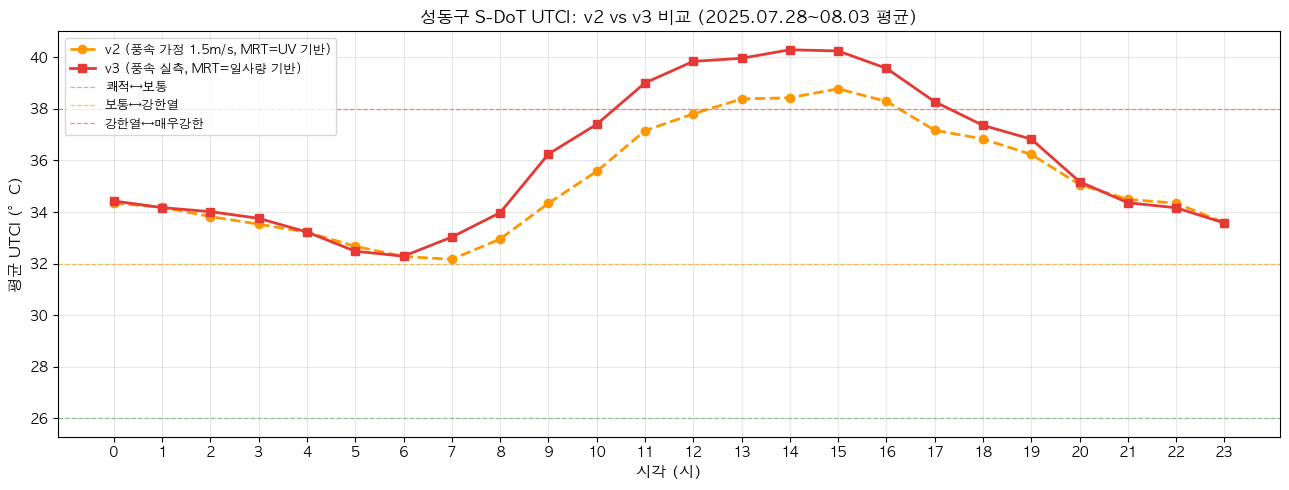


v3 - v2 차이 (양수=v3가 더 높음, 음수=v3가 더 낮음):
  00시: +0.08°C ↑
  01시: -0.01°C ↓
  02시: +0.19°C ↑
  03시: +0.23°C ↑
  04시: +0.01°C ↑
  05시: -0.19°C ↓
  06시: +0.01°C ↑
  07시: +0.86°C ↑
  08시: +1.02°C ↑
  09시: +1.91°C ↑
  10시: +1.83°C ↑
  11시: +1.85°C ↑
  12시: +2.03°C ↑
  13시: +1.58°C ↑
  14시: +1.86°C ↑
  15시: +1.47°C ↑
  16시: +1.28°C ↑
  17시: +1.11°C ↑
  18시: +0.53°C ↑
  19시: +0.59°C ↑
  20시: +0.11°C ↑
  21시: -0.13°C ↓
  22시: -0.18°C ↓
  23시: -0.01°C ↓


In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

v2_hourly = v2_ref.groupby('hour')['utci_val'].mean()
v3_hourly = df.groupby('hour')['utci_v3'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(v2_hourly.index, v2_hourly.values, 'o--', color='#FF9800',
        linewidth=2, markersize=6, label='v2 (풍속 가정 1.5m/s, MRT=UV 기반)')
ax.plot(v3_hourly.index, v3_hourly.values, 's-',  color='#E53935',
        linewidth=2, markersize=6, label='v3 (풍속 실측, MRT=일사량 기반)')

for threshold, label, color in [(26,'쾌적↔보통','#4CAF50'),
                                  (32,'보통↔강한열','#FF9800'),
                                  (38,'강한열↔매우강한','#F44336')]:
    ax.axhline(threshold, color=color, linestyle='--', linewidth=0.9, alpha=0.6, label=label)

ax.set_xlabel('시각 (시)', fontsize=11)
ax.set_ylabel('평균 UTCI (°C)', fontsize=11)
ax.set_title('성동구 S-DoT UTCI: v2 vs v3 비교 (2025.07.28~08.03 평균)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../05_시각화/utci_v2_vs_v3.png', dpi=150, bbox_inches='tight')
plt.show()

diff = (v3_hourly - v2_hourly).round(2)
print('\nv3 - v2 차이 (양수=v3가 더 높음, 음수=v3가 더 낮음):')
for h, d in diff.items():
    sign = '↑' if d > 0 else ('↓' if d < 0 else '=')
    print(f'  {h:02d}시: {d:+.2f}°C {sign}')

## 6. 위치 조인 + 저장

In [7]:
merged = df.merge(loc_sdong[['serial','lat','lon','address']], on='serial', how='inner')
print(f'위치 조인: {len(merged):,}행 / 센서 {merged["serial"].nunique()}개')

out_cols = ['serial','dt','date','hour','dong','lat','lon',
            'temp','humi','v','tr_v3','utci_v3','utci_cat']
merged[out_cols].to_csv(OUT_DIR / 'sdot_utci_v3_seongdong.csv',
                         index=False, encoding='utf-8-sig')

print('저장 완료: 04_분석결과/sdot_utci_v3_seongdong.csv')
print('\n시간대별 평균 UTCI (v3):')
summary = merged.groupby('hour')['utci_v3'].mean().round(1)
for h, v in summary.items():
    grade = '🔥' if v >= 38 else ('🌡' if v >= 32 else '😊')
    print(f'  {h:02d}시: {v}°C {grade}')

위치 조인: 6,314행 / 센서 57개
저장 완료: 04_분석결과/sdot_utci_v3_seongdong.csv

시간대별 평균 UTCI (v3):
  00시: 34.4°C 🌡
  01시: 34.2°C 🌡
  02시: 34.0°C 🌡
  03시: 33.8°C 🌡
  04시: 33.2°C 🌡
  05시: 32.5°C 🌡
  06시: 32.3°C 🌡
  07시: 33.0°C 🌡
  08시: 34.0°C 🌡
  09시: 36.2°C 🌡
  10시: 37.4°C 🌡
  11시: 39.0°C 🔥
  12시: 39.8°C 🔥
  13시: 40.0°C 🔥
  14시: 40.3°C 🔥
  15시: 40.2°C 🔥
  16시: 39.6°C 🔥
  17시: 38.3°C 🔥
  18시: 37.4°C 🌡
  19시: 36.8°C 🌡
  20시: 35.2°C 🌡
  21시: 34.4°C 🌡
  22시: 34.2°C 🌡
  23시: 33.6°C 🌡
